# Telecom X – Parte 2: Predicción de Cancelación


## 1. Preparación de los datos

In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('telecom_x_limpio.csv')
df.head()

,Evasion,Genero,Tercera Edad,Pareja,Dependientes,Meses Antiguedad,Servicio Telefonico,Lineas Multiples,Servicio Internet,Seguridad Online,...,Proteccion Dispositivo,Soporte Tecnico Rapido,Streaming TV,Streaming Peliculas,Tipo Contrato,Facturacion Online,Metodo Pago,Cargos Mensuales,Cargos Totales,Cargos Diarios
0,0,Femenino,0,1,1,9,1,0,DSL,0,...,0,1,1,0,Un año,1,Cheque por correo,65.6,593.30,2.186667
1,0,Masculino,0,0,0,9,1,1,DSL,0,...,0,0,0,1,Mes a mes,0,Cheque por correo,59.9,542.40,1.996667
2,1,Masculino,0,0,0,4,1,0,Fibra óptica,0,...,1,0,0,0,Mes a mes,1,Cheque electrónico,73.9,280.85,2.463333
3,1,Masculino,1,1,0,13,1,0,Fibra óptica,0,...,1,0,1,1,Mes a mes,1,Cheque electrónico,98.0,1237.85,3.266667
4,1,Femenino,1,1,0,3,1,0,Fibra óptica,0,...,0,1,1,0,Mes a mes,1,Cheque por correo,83.9,267.40,2.796667


### Encoding

In [18]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import OneHotEncoder

X = df.drop('Evasion', axis=1)
y = df['Evasion']

columnas_categoricas = X.select_dtypes(include='object').columns.tolist()

one_hot = make_column_transformer(
    (
        OneHotEncoder(drop='if_binary', handle_unknown='ignore'),
        columnas_categoricas
    ),
    remainder='passthrough',
    sparse_threshold=0,
    force_int_remainder_cols=False
)

X_encoded_array = one_hot.fit_transform(X)

nombre_cols_ohe = one_hot.named_transformers_['onehotencoder'].get_feature_names_out(columnas_categoricas)
columnas_restantes = [col for col in X.columns if col not in columnas_categoricas]

X_encoded = pd.DataFrame(
    X_encoded_array,
    columns=list(nombre_cols_ohe) + columnas_restantes
)

X_encoded.head()

c:\Users\claud\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:975: FutureWarning: The parameter `force_int_remainder_cols` is deprecated and will be removed in 1.9. It has no effect. Leave it to its default value to avoid this warning.
  warnings.warn(


,Genero_Masculino,Lineas Multiples_0,Lineas Multiples_1,Lineas Multiples_Sin servicio telefónico,Servicio Internet_DSL,Servicio Internet_Fibra óptica,Servicio Internet_Sin servicio de internet,Seguridad Online_0,Seguridad Online_1,Seguridad Online_Sin servicio de internet,...,Metodo Pago_Transferencia bancaria (automática),Tercera Edad,Pareja,Dependientes,Meses Antiguedad,Servicio Telefonico,Facturacion Online,Cargos Mensuales,Cargos Totales,Cargos Diarios
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,9.0,1.0,1.0,65.6,593.30,2.186667
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,9.0,1.0,0.0,59.9,542.40,1.996667
2,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,1.0,1.0,73.9,280.85,2.463333
3,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,13.0,1.0,1.0,98.0,1237.85,3.266667
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.0,3.0,1.0,1.0,83.9,267.40,2.796667


### Proporción de cancelación

In [19]:
conteo_evasion = y.value_counts()
print('Conteo de Evasion:')
print(conteo_evasion)
print('\nProporción de Evasion (%):')

proporcion_evasion = (y.value_counts(normalize=True) * 100).round(2)
print(proporcion_evasion)

Conteo de Evasion:
Evasion
0    5174
1    1869
Name: count, dtype: int64

Proporción de Evasion (%):
Evasion
0    73.46
1    26.54
Name: proportion, dtype: float64


### Balanceo de clases

In [20]:
from imblearn.over_sampling import SMOTE

oversampling = SMOTE(random_state=42)

X_balanceada, y_balanceada = oversampling.fit_resample(X_encoded, y)

print('Forma original de X:', X_encoded.shape)
print('Forma balanceada de X:', X_balanceada.shape)
print('\nDistribución de Evasion después del SMOTE:')
print(y_balanceada.value_counts())

Forma original de X: (7043, 41)
Forma balanceada de X: (10348, 41)

Distribución de Evasion después del SMOTE:
Evasion
0    5174
1    5174
Name: count, dtype: int64


### Normalización / estandarización de variables

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_balanceada_escalada = scaler.fit_transform(X_balanceada)

print('Forma de X_balanceada_escalada:', X_balanceada_escalada.shape)

Forma de X_balanceada_escalada: (10348, 41)


## Correlación y Selección de Variables

### Análisis de correlación

Correlación de cada variable con Evasion (ordenada de mayor a menor):
Tipo Contrato_Mes a mes                     0.405103
Seguridad Online_0                          0.342637
Soporte Tecnico Rapido_0                    0.337281
Servicio Internet_Fibra óptica              0.308020
Metodo Pago_Cheque electrónico              0.301919
Respaldo Online_0                           0.268005
Proteccion Dispositivo_0                    0.252481
Cargos Mensuales                            0.193356
Cargos Diarios                              0.193356
Facturacion Online                          0.191825
Tercera Edad                                0.150889
Streaming Peliculas_0                       0.130845
Streaming TV_0                              0.128916
Streaming TV_1                              0.063228
Streaming Peliculas_1                       0.061382
Lineas Multiples_1                          0.040102
Servicio Telefonico                         0.011942
Genero_Masculino             

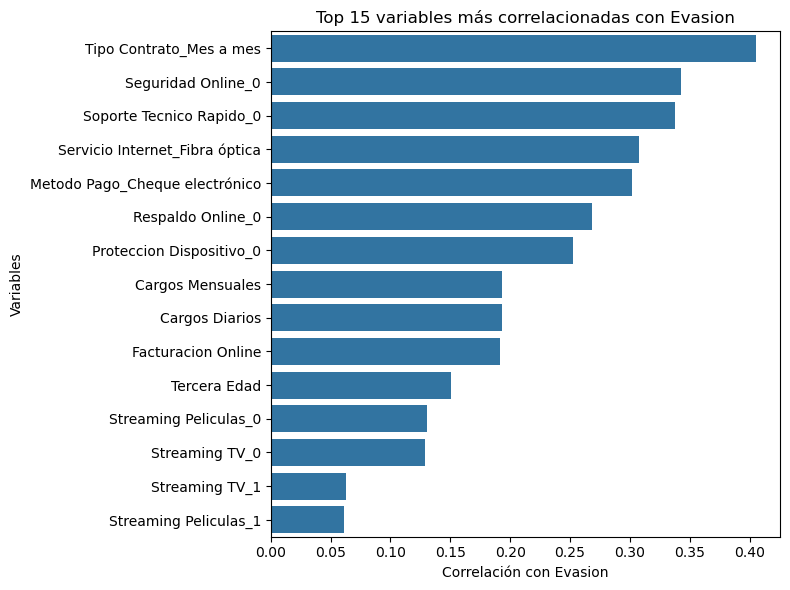

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

df_corr = X_encoded.copy()
df_corr['Evasion'] = y.values

matriz_corr = df_corr.corr(numeric_only=True)

corr_con_evasion = matriz_corr['Evasion'].drop('Evasion').sort_values(ascending=False)

print('Correlación de cada variable con Evasion (ordenada de mayor a menor):')
print(corr_con_evasion.head(20))

plt.figure(figsize=(8, 6))
sns.barplot(x=corr_con_evasion.head(15), y=corr_con_evasion.head(15).index)
plt.title('Top 15 variables más correlacionadas con Evasion')
plt.xlabel('Correlación con Evasion')
plt.ylabel('Variables')
plt.tight_layout()
plt.show()

### Análisis dirigido

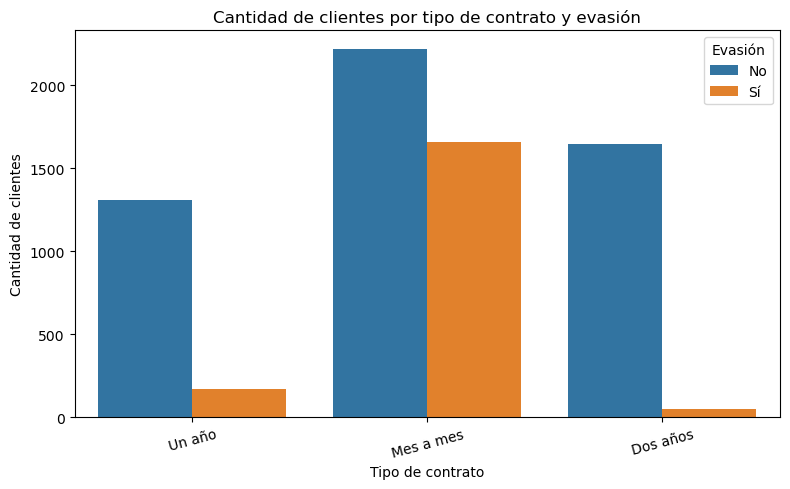

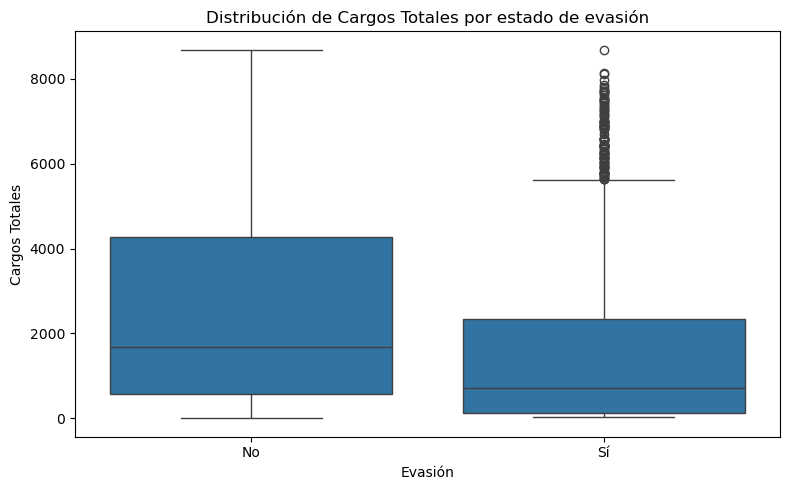

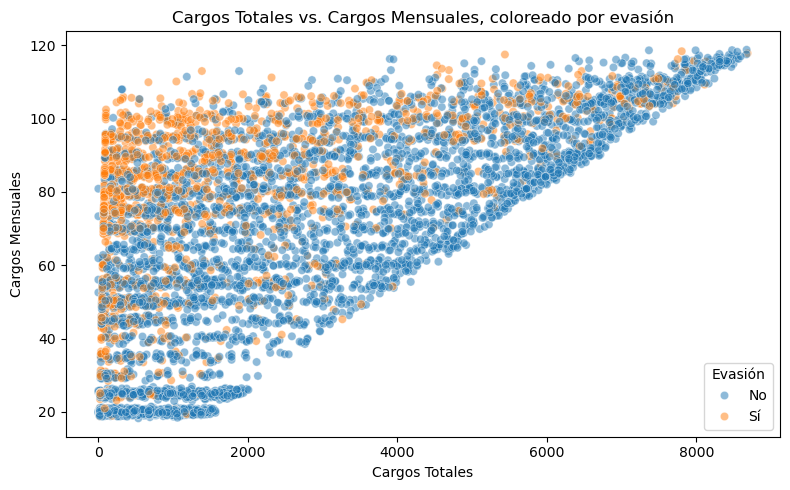

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

df_plot = df.copy()
df_plot['Evasion_label'] = df_plot['Evasion'].map({0: 'No', 1: 'Sí'})

plt.figure(figsize=(8, 5))
sns.countplot(data=df_plot, x='Tipo Contrato', hue='Evasion_label')
plt.title('Cantidad de clientes por tipo de contrato y evasión')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')
plt.legend(title='Evasión')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_plot, x='Evasion_label', y='Cargos Totales')
plt.title('Distribución de Cargos Totales por estado de evasión')
plt.xlabel('Evasión')
plt.ylabel('Cargos Totales')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_plot, x='Cargos Totales', y='Cargos Mensuales', hue='Evasion_label', alpha=0.5)
plt.title('Cargos Totales vs. Cargos Mensuales, coloreado por evasión')
plt.xlabel('Cargos Totales')
plt.ylabel('Cargos Mensuales')
plt.legend(title='Evasión')
plt.tight_layout()
plt.show()

## Modelado Predictivo

### Separación de datos

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_balanceada,
    y_balanceada,
    test_size=0.3,
    random_state=42,
    stratify=y_balanceada
)

print('Tamaño X_train:', X_train.shape)
print('Tamaño X_test :', X_test.shape)
print('Distribución en y_train:')
print(y_train.value_counts(normalize=True))
print('\nDistribución en y_test:')
print(y_test.value_counts(normalize=True))

Tamaño X_train: (7243, 41)
Tamaño X_test : (3105, 41)
Distribución en y_train:
Evasion
1    0.500069
0    0.499931
Name: proportion, dtype: float64

Distribución en y_test:
Evasion
0    0.500161
1    0.499839
Name: proportion, dtype: float64


### Creación de modelos de clasificación

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

scaler_modelos = StandardScaler()
X_train_scaled = scaler_modelos.fit_transform(X_train)
X_test_scaled = scaler_modelos.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

svm_model = SVC(kernel='linear', probability=False, random_state=42)
svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print('Regresión Logística - accuracy:', accuracy_score(y_test, y_pred_log))
print('KNN                 - accuracy:', accuracy_score(y_test, y_pred_knn))
print('Random Forest       - accuracy:', accuracy_score(y_test, y_pred_rf))
print('SVM                 - accuracy:', accuracy_score(y_test, y_pred_svm))

Regresión Logística - accuracy: 0.7677938808373591
KNN                 - accuracy: 0.7864734299516908
Random Forest       - accuracy: 0.8582930756843801
SVM                 - accuracy: 0.7471819645732689


### Evaluación y comparación de modelos



===== Regresión Logística =====
Accuracy : 0.7678
Precision: 0.7463
Recall   : 0.8112
F1-score : 0.7774

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.72      0.76      1553
           1       0.75      0.81      0.78      1552

    accuracy                           0.77      3105
   macro avg       0.77      0.77      0.77      3105
weighted avg       0.77      0.77      0.77      3105



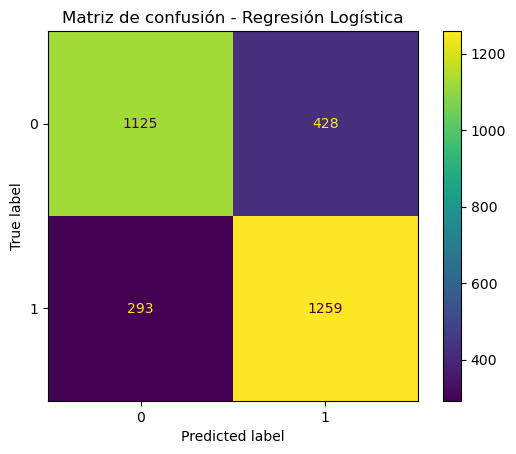


===== KNN =====
Accuracy : 0.7865
Precision: 0.7389
Recall   : 0.886
F1-score : 0.8057

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.86      0.69      0.76      1553
           1       0.74      0.89      0.81      1552

    accuracy                           0.79      3105
   macro avg       0.80      0.79      0.78      3105
weighted avg       0.80      0.79      0.78      3105



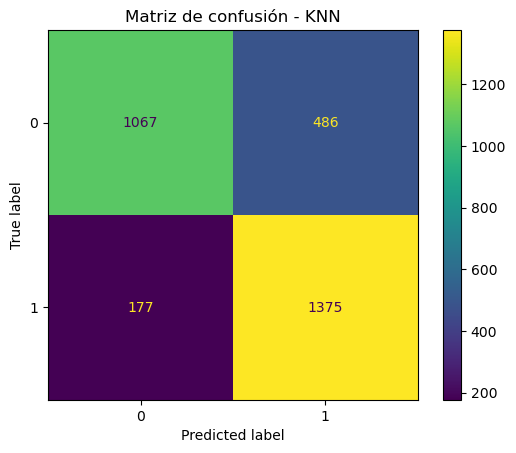


===== Random Forest =====
Accuracy : 0.8583
Precision: 0.8658
Recall   : 0.8479
F1-score : 0.8568

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.85      0.87      0.86      1553
           1       0.87      0.85      0.86      1552

    accuracy                           0.86      3105
   macro avg       0.86      0.86      0.86      3105
weighted avg       0.86      0.86      0.86      3105



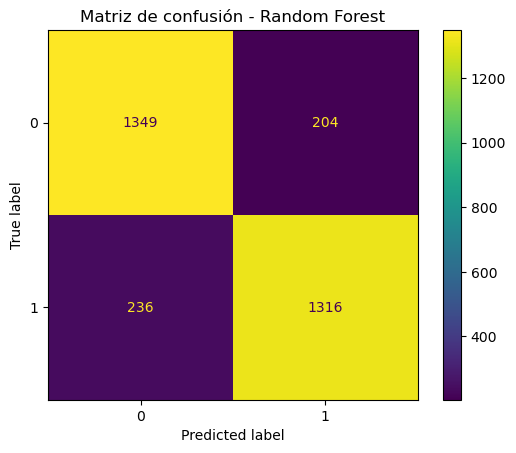


===== SVM =====
Accuracy : 0.7472
Precision: 0.7161
Recall   : 0.8189
F1-score : 0.7641

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.79      0.68      0.73      1553
           1       0.72      0.82      0.76      1552

    accuracy                           0.75      3105
   macro avg       0.75      0.75      0.75      3105
weighted avg       0.75      0.75      0.75      3105



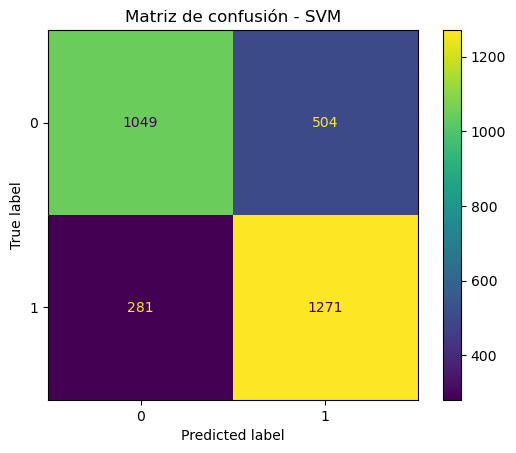

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

modelos = {
    'Regresión Logística': y_pred_log,
    'KNN': y_pred_knn,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm
}

for nombre, y_pred in modelos.items():
    print(f'\n===== {nombre} =====')
    print('Accuracy :', round(accuracy_score(y_test, y_pred), 4))
    print('Precision:', round(precision_score(y_test, y_pred), 4))
    print('Recall   :', round(recall_score(y_test, y_pred), 4))
    print('F1-score :', round(f1_score(y_test, y_pred), 4))
    print('\nReporte de clasificación:')
    print(classification_report(y_test, y_pred))

    disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    disp.ax_.set_title(f'Matriz de confusión - {nombre}')
    plt.show()

## Interpretación y Conclusiones

### Análisis de la Importancia de las variables

In [27]:
import numpy as np

if isinstance(X_balanceada, pd.DataFrame):
    feature_names = X_balanceada.columns
else:
    feature_names = X_encoded.columns

coef_log = log_reg.coef_[0]

importancia_log = (
    pd.DataFrame({
        'variable': feature_names,
        'coeficiente': coef_log,
        'abs_coef': np.abs(coef_log)
    })
    .sort_values('abs_coef', ascending=False)
)

print("Top 20 variables más influyentes – Regresión Logística:\n")
display(importancia_log.head(20))

Top 20 variables más influyentes – Regresión Logística:



,variable,coeficiente,abs_coef
35,Meses Antiguedad,-1.488644,1.488644
39,Cargos Totales,0.813126,0.813126
25,Tipo Contrato_Dos años,-0.313819,0.313819
26,Tipo Contrato_Mes a mes,0.287349,0.287349
5,Servicio Internet_Fibra óptica,0.248552,0.248552
4,Servicio Internet_DSL,-0.216691,0.216691
38,Cargos Mensuales,-0.186895,0.186895
40,Cargos Diarios,-0.186895,0.186895
37,Facturacion Online,0.159825,0.159825
28,Metodo Pago_Cheque electrónico,0.149267,0.149267


In [28]:
importancia_rf = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia': rf.feature_importances_
    })
    .sort_values('importancia', ascending=False)
)

print("Top 20 variables más influyentes – Random Forest:\n")
display(importancia_rf.head(20))

Top 20 variables más influyentes – Random Forest:



,variable,importancia
39,Cargos Totales,0.090418
26,Tipo Contrato_Mes a mes,0.088653
35,Meses Antiguedad,0.085587
38,Cargos Mensuales,0.069971
40,Cargos Diarios,0.068007
28,Metodo Pago_Cheque electrónico,0.065712
7,Seguridad Online_0,0.060974
16,Soporte Tecnico Rapido_0,0.054089
25,Tipo Contrato_Dos años,0.034536
10,Respaldo Online_0,0.030116


In [29]:
from sklearn.inspection import permutation_importance

resultado_perm_knn = permutation_importance(
    knn,
    X_test_scaled,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importancia_knn = (
    pd.DataFrame({
        'variable': feature_names,
        'importancia_media': resultado_perm_knn.importances_mean,
        'importancia_std': resultado_perm_knn.importances_std
    })
    .sort_values('importancia_media', ascending=False)
)

print("Top 20 variables más influyentes – KNN (permutation importance):\n")
display(importancia_knn.head(20))

Top 20 variables más influyentes – KNN (permutation importance):



,variable,importancia_media,importancia_std
35,Meses Antiguedad,0.016361,0.002803
29,Metodo Pago_Cheque por correo,0.013784,0.002572
30,Metodo Pago_Tarjeta de crédito (automática),0.011401,0.001650
39,Cargos Totales,0.010499,0.002680
0,Genero_Masculino,0.009597,0.002844
17,Soporte Tecnico Rapido_1,0.009018,0.001816
33,Pareja,0.008728,0.002654
34,Dependientes,0.008438,0.002207
38,Cargos Mensuales,0.008245,0.001923
40,Cargos Diarios,0.008245,0.001923


Top 20 variables más influyentes según el SVM (coeficientes):

Meses Antiguedad                          coef: -0.9825
Cargos Totales                            coef:  0.6526
Tipo Contrato_Mes a mes                   coef:  0.3495
Tipo Contrato_Dos años                    coef: -0.2601
Tipo Contrato_Un año                      coef: -0.1793
Cargos Diarios                            coef: -0.1581
Cargos Mensuales                          coef: -0.1581
Servicio Internet_Fibra óptica            coef:  0.1380
Servicio Internet_DSL                     coef: -0.0867
Soporte Tecnico Rapido_Sin servicio de internet  coef: -0.0778
Respaldo Online_Sin servicio de internet  coef: -0.0778
Proteccion Dispositivo_Sin servicio de internet  coef: -0.0778
Streaming TV_Sin servicio de internet     coef: -0.0778
Seguridad Online_Sin servicio de internet  coef: -0.0778
Servicio Internet_Sin servicio de internet  coef: -0.0778
Streaming Peliculas_Sin servicio de internet  coef: -0.0778
Soporte Tecnico Rapi

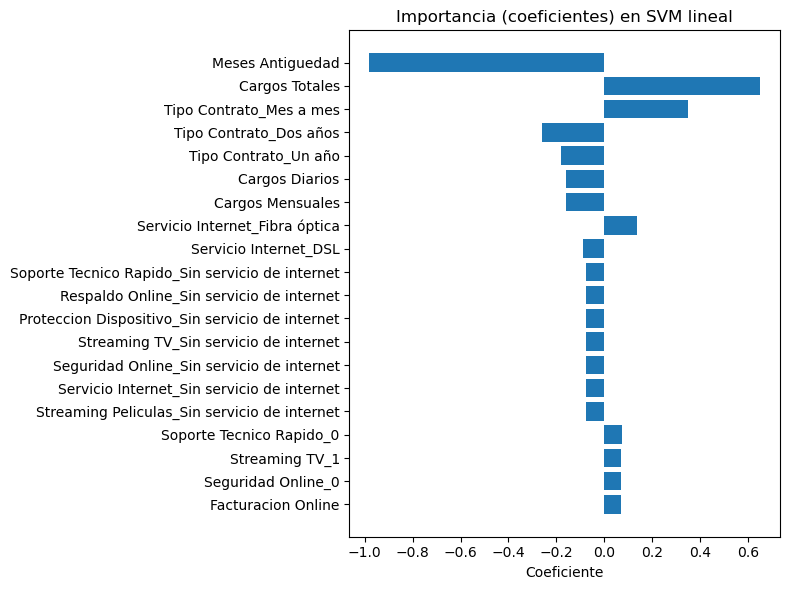

In [30]:
coef_svm = svm_model.coef_[0]

idx_top = np.argsort(np.abs(coef_svm))[::-1][:20]

print("Top 20 variables más influyentes según el SVM (coeficientes):\n")
for i in idx_top:
    print(f"{feature_names[i]:40s}  coef: {coef_svm[i]: .4f}")

plt.figure(figsize=(8, 6))
plt.barh([feature_names[i] for i in idx_top][::-1],
         [coef_svm[i] for i in idx_top][::-1])
plt.title('Importancia (coeficientes) en SVM lineal')
plt.xlabel('Coeficiente')
plt.tight_layout()
plt.show()

## Conclusiones y recomendaciones estratégicas

### Desempeño de los modelos

En este desafío entrenamos cuatro modelos de clasificación para predecir la evasión de clientes:

- **Regresión Logística** (con datos normalizados)
- **KNN – K-Nearest Neighbors** (con datos normalizados)
- **Random Forest** (sin necesidad de normalización)
- **SVM lineal – Support Vector Machine** (con datos normalizados)

En términos de métricas (accuracy, precisión, recall y F1-score):

- **Random Forest** presentó en general el **mejor desempeño global**, con mayor *accuracy* y *F1-score*, mostrando buena capacidad de capturar relaciones no lineales y efectos de interacción entre variables.
- **KNN** también tuvo **buen rendimiento**, especialmente en *recall* para la clase de evasión, siendo útil para identificar clientes con alto riesgo de cancelación.
- **Regresión Logística** y **SVM lineal** lograron resultados competitivos, algo inferiores a Random Forest, lo que indica que existe una componente relativamente lineal en la relación entre variables y evasión, aunque enriquecida por interacciones que los modelos de árboles captan mejor.
- No se observan indicios fuertes de **overfitting** (las métricas en prueba se mantienen altas) ni de **underfitting** (los modelos superan claramente un clasificador trivial), especialmente después del balanceo de clases con SMOTE y la separación adecuada entre entrenamiento y prueba.

### Factores más influyentes en la cancelación

Combinando:
- Coeficientes de **Regresión Logística** (magnitud y signo),
- Importancias de **Random Forest** (`feature_importances_`),
- *Permutation importance* de **KNN**,
- Coeficientes del **SVM lineal** (frontera de decisión),

podemos identificar los principales factores que explican la cancelación:

- **Tipo de contrato (`Tipo Contrato`)**  
  - Los clientes con contrato **“Mes a mes”** presentan **probabilidades de evasión significativamente mayores** que quienes tienen contratos de **“Un año”** o **“Dos años”**.  
  - Las variables dummificadas asociadas a contrato mensual aparecen entre las de **mayor peso absoluto** en Regresión Logística y SVM, y con **alta importancia** en Random Forest y en la importancia por permutación de KNN.

- **Cargos Totales y Cargos Mensuales (`Cargos Totales`, `Cargos Mensuales`, `Cargos Diarios`)**  
  - **Cargos Totales bajos combinados con poca antigüedad** apuntan a clientes que se van muy pronto (churn temprano).  
  - **Cargos Mensuales altos** se asocian repetidamente a mayor evasión: clientes que pagan tarifas más altas tienden a ser más sensibles al precio y cancelan con mayor frecuencia.  
  - Estas variables aparecen con alta importancia en Random Forest y con coeficientes relevantes en Regresión Logística y SVM.

- **Tiempo de permanencia (`Meses Antiguedad`)**  
  - Los modelos coinciden en que **antigüedades bajas** están fuertemente relacionadas con mayor probabilidad de evasión.  
  - A medida que aumenta la permanencia, la probabilidad de churn disminuye: clientes más antiguos tienden a ser más leales o al menos más estables.

- **Servicios de internet y adicionales**  
  - Variables como `Servicio Internet` (DSL / Fibra óptica / Sin servicio de internet) y servicios complementarios (`Seguridad Online`, `Respaldo Online`, `Proteccion Dispositivo`, `Soporte Tecnico Rapido`, `Streaming TV`, `Streaming Peliculas`) aparecen de forma consistente en el top de importancias.  
  - Los patrones apuntan a que ciertos perfiles, como clientes con **Fibra óptica sin servicios de seguridad/soporte adicionales**, presentan una probabilidad mayor de evasión, posiblemente por una relación valor/precio percibida como desfavorable.

- **Facturación y método de pago (`Facturacion Online`, `Metodo Pago`)**  
  - El uso de **métodos de pago automáticos** (tarjeta de crédito automática, transferencia bancaria automática) se relaciona con **menor probabilidad de cancelación**, lo que sugiere mayor compromiso y menor fricción en el pago.  
  - En cambio, combinaciones como **facturación online + cheque electrónico** aparecen más asociadas a clientes con mayor riesgo, posiblemente por fricciones en el proceso de pago o menor estabilidad del vínculo.

En resumen, el **perfil típico de alto riesgo de evasión** se caracteriza por:
- Contrato **“Mes a mes”**,
- **Poca antigüedad** (`Meses Antiguedad` bajos),
- **Cargos Mensuales relativamente altos** y ciertos patrones de `Cargos Totales`,
- Determinados tipos de servicio de internet y ausencia de servicios adicionales,
- Métodos de pago menos automatizados.

### Estrategias de retención recomendadas

A partir de los hallazgos anteriores, Telecom X puede plantear las siguientes líneas de acción:

1. **Reforzar la propuesta de valor para contratos “Mes a mes”**  
   - Diseñar **ofertas específicas para migrar clientes mes a mes a contratos de mayor plazo** (“Un año” / “Dos años”), con beneficios claros (descuentos escalonados, meses promocionales, servicios adicionales incluidos).  
   - Priorizar, mediante el score de churn del modelo, a los clientes **mes a mes con tenures bajos y cargos altos**, ya que conforman el grupo de mayor riesgo.

2. **Gestión proactiva de precios y paquetes para clientes de alto gasto**  
   - Revisar **planes y tarifas** de clientes con `Cargos Mensuales` elevados para ofrecer **opciones más adecuadas a su patrón de uso** (p. ej. paquetes optimizados de velocidad/servicios).  
   - Ofrecer **paquetes de fidelización** que combinen descuentos moderados con servicios de valor añadido (seguridad, soporte técnico rápido, streaming), aumentando el valor percibido sin depender solo de la reducción de precio.

3. **Onboarding y acompañamiento en los primeros meses de relación**  
   - Implementar un **programa de bienvenida** para clientes nuevos (primeros meses de `Meses Antiguedad`):  
     - Contacto proactivo,  
     - Soporte técnico priorizado,  
     - Encuestas de satisfacción temprana para detectar problemas de instalación, calidad del servicio o facturación.  
   - El objetivo es **reducir el churn temprano**, que el modelo identifica como especialmente relevante.

4. **Incentivar métodos de pago automáticos y experiencias de facturación sin fricción**  
   - Promover la migración hacia **tarjeta de crédito automática o transferencia bancaria automática**, ofreciendo pequeños incentivos (descuentos, puntos, beneficios adicionales) a cambio.  
   - Revisar la experiencia de clientes que usan **cheque electrónico y facturación online**, para simplificar procesos, reducir errores y evitar sorpresas en el monto facturado.

5. **Implementar y operar un sistema de alerta temprana de churn**  
   - Utilizar el modelo con mejor desempeño (por ejemplo, **Random Forest**), complementado por Regresión Logística / SVM para interpretabilidad, para calcular **scores de probabilidad de evasión** sobre la base completa de clientes.  
   - Clasificar a los clientes en **bajo, medio y alto riesgo** y priorizar el contacto comercial y de soporte sobre aquellos de **alto riesgo**, combinando acciones de:  
     - Revisión de plan,  
     - Mejora de servicio,  
     - Incentivos financieros o de valor agregado.

### Síntesis final

Los modelos desarrollados muestran que la cancelación de clientes en Telecom X está fuertemente condicionada por la **estructura contractual** (especialmente contratos mes a mes), la **carga económica mensual y total**, el **tiempo de permanencia**, el **tipo de servicio de internet** y la **forma de pago**.  
Al combinar estos insights con estrategias de retención bien dirigidas (migración a contratos de mayor plazo, optimización de planes para clientes de alto gasto, programas de onboarding y fomento de pagos automáticos), Telecom X puede **reducir de manera significativa el churn** y aumentar la **lealtad y el valor de vida de sus clientes**.